## READMISSION RISK PREDICTION WITH RANDOM FOREST MODEL
This model was developed using data from the first 24 hours of each stay_id to predict the risk of patient readmission.The dataset was initially split into training, validation, and test sets, with the majority of the data allocated to the training set. Each dataset was preprocessed separately. 

After the data was split, the most important features for the Random Forest model were identified and retained. To further refine the feature set, the correlation matrix of these important features was evaluated, and decisions were made to exclude features that exhibited high multicollinearity (correlation greater than 80%). When two features were found to be highly correlated, the one with fewer missing values in the initial unprocessed DataFrame was retained. For instance, "Base Excess" and "Calculated Total CO2" had a 92% correlation, but since "Base Excess" had significantly more missing values, it was excluded, and "Calculated Total CO2" was kept in the model.

In addition to the selected features, a function, icu_stay, was added, which represents the day of the patient's ICU stay relative to the date of the current record. For example, if a patient's data is from the third day of their ICU stay, the icu_stay feature would be assigned a value of 3. This feature was intended to capture the temporal progression of the patient's condition during their ICU stay and was planned to be included in the real-time model.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import random
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import classification_report, confusion_matrix
from datetime import datetime, timedelta
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils import resample
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, roc_curve, auc, make_scorer, f1_score

In [2]:
os.chdir('/workspaces/xitaso/data')

In [3]:
ROOT_FOLDER = os.path.dirname(os.getcwd())
PROCESSED_DATA =  os.path.join(ROOT_FOLDER, "data","processed")

In [4]:
ICU_STAYS = os.path.join(PROCESSED_DATA,"icustays_20240512.feather")
ICU_TIMESERIES_FEATURES = os.path.join(PROCESSED_DATA,"icu_timeseries_features_0M_0ed859c799267d4ae737f8814d52726d_20240512.feather")
ICU_OUTPUT_EVENTS = os.path.join(PROCESSED_DATA,"icu_outputevents_0M_0ed859c799267d4ae737f8814d52726d_20240512.feather")
icu_stays_df = pd.read_feather(ICU_STAYS)
icu_timeseries_features_df = pd.read_feather(ICU_TIMESERIES_FEATURES)
icu_output_events_df = pd.read_feather(ICU_OUTPUT_EVENTS)

In [5]:
icu_stays_df.head()

,subject_id,hadm_id,icu_stay_id,first_careunit,icu_intime,icu_outtime,icu_los,hours_until_readmission,will_be_readmitted,hours_to_readmission,stay_is_readmission
0,10018328,23786647,31269608,Neuro Stepdown,2154-04-24 23:03:44,2154-05-02 15:55:21,7.702512,NaN,False,NaN,False
1,10020187,24104168,37509585,Neuro Surgical Intensive Care Unit (Neuro SICU),2169-01-15 04:56:00,2169-01-20 15:47:50,5.452662,NaN,False,NaN,False
2,10020187,26842957,32554129,Neuro Intermediate,2170-02-24 18:18:46,2170-02-25 15:15:26,0.872685,NaN,False,NaN,False
3,10012853,27882036,31338022,Trauma SICU (TSICU),2176-11-26 02:34:49,2176-11-29 20:58:54,3.766725,NaN,False,NaN,False
4,10020740,25826145,32145159,Trauma SICU (TSICU),2150-06-03 20:12:32,2150-06-04 21:05:58,1.037106,NaN,False,NaN,False


In [6]:
icu_timeseries_features_df.head()

,abs_event_time,stay_id,Activity / Mobility (JH-HLM),Apnea Interval,Arterial Blood Pressure Alarm - High,Arterial Blood Pressure Alarm - Low,Arterial Blood Pressure diastolic,Arterial Blood Pressure mean,Arterial Blood Pressure systolic,Current Dyspnea Assessment,...,RDW-SD,Red Blood Cells,Sodium,"Sodium, Whole Blood",Temperature,Urea Nitrogen,White Blood Cells,pCO2,pH,pO2
0,1970-01-01 01:00:00,30057454,NaN,NaN,NaN,NaN,64.800000,75.0,96.800000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1970-01-01 02:00:00,30057454,NaN,NaN,NaN,NaN,62.333333,72.0,93.333333,NaN,...,NaN,4.73,139.0,NaN,NaN,45.0,12.7,NaN,NaN,NaN
2,1970-01-01 03:00:00,30057454,NaN,NaN,NaN,NaN,64.000000,76.0,99.000000,NaN,...,NaN,4.73,139.0,NaN,NaN,45.0,12.7,45.0,7.4,76.0
3,1970-01-01 04:00:00,30057454,NaN,NaN,NaN,NaN,67.000000,78.0,102.000000,NaN,...,NaN,4.73,139.0,NaN,NaN,45.0,12.7,45.0,7.4,76.0
4,1970-01-01 05:00:00,30057454,NaN,NaN,NaN,NaN,67.000000,79.0,105.000000,NaN,...,NaN,4.73,139.0,NaN,NaN,45.0,12.7,45.0,7.4,76.0


In [7]:
icu_output_events_df.head()

,stay_id,urine_last_1d
0,30057454,1621
1,30101877,1857
2,30425410,1070
3,30458995,1760
4,30585761,2010


In [8]:
icu_stays_df['stay_id'] = icu_stays_df['icu_stay_id']
icu_stays_df.head()

,subject_id,hadm_id,icu_stay_id,first_careunit,icu_intime,icu_outtime,icu_los,hours_until_readmission,will_be_readmitted,hours_to_readmission,stay_is_readmission,stay_id
0,10018328,23786647,31269608,Neuro Stepdown,2154-04-24 23:03:44,2154-05-02 15:55:21,7.702512,NaN,False,NaN,False,31269608
1,10020187,24104168,37509585,Neuro Surgical Intensive Care Unit (Neuro SICU),2169-01-15 04:56:00,2169-01-20 15:47:50,5.452662,NaN,False,NaN,False,37509585
2,10020187,26842957,32554129,Neuro Intermediate,2170-02-24 18:18:46,2170-02-25 15:15:26,0.872685,NaN,False,NaN,False,32554129
3,10012853,27882036,31338022,Trauma SICU (TSICU),2176-11-26 02:34:49,2176-11-29 20:58:54,3.766725,NaN,False,NaN,False,31338022
4,10020740,25826145,32145159,Trauma SICU (TSICU),2150-06-03 20:12:32,2150-06-04 21:05:58,1.037106,NaN,False,NaN,False,32145159


In [9]:
# Create 'readmitted' column based on 'hours_until_readmission'
icu_stays_df['readmitted'] = icu_stays_df['hours_until_readmission'].apply(lambda x: 1 if x <= 720 else 0)
icu_stays_df['readmitted'] = icu_stays_df['readmitted'].fillna(0).astype(int)
icu_stays_df[['subject_id','stay_id','hours_until_readmission', 'readmitted', 'will_be_readmitted']].head()

,subject_id,stay_id,hours_until_readmission,readmitted,will_be_readmitted
0,10018328,31269608,NaN,0,False
1,10020187,37509585,NaN,0,False
2,10020187,32554129,NaN,0,False
3,10012853,31338022,NaN,0,False
4,10020740,32145159,NaN,0,False


In [10]:
# Select only the required columns from icu_stays_df
icu_stays_df = icu_stays_df[['subject_id', 'stay_id', 'readmitted', 'icu_intime' , 'icu_outtime' , 'will_be_readmitted']]

# Ensure 'stay_id' is of type int64 in both DataFrames
icu_stays_df['stay_id'] = icu_stays_df['stay_id'].astype('int64')
icu_timeseries_features_df['stay_id'] = icu_timeseries_features_df['stay_id'].astype('int64')

merged_df = pd.merge(icu_stays_df,icu_timeseries_features_df, on='stay_id')
merged_df.head()

,subject_id,stay_id,readmitted,icu_intime,icu_outtime,will_be_readmitted,abs_event_time,Activity / Mobility (JH-HLM),Apnea Interval,Arterial Blood Pressure Alarm - High,...,RDW-SD,Red Blood Cells,Sodium,"Sodium, Whole Blood",Temperature,Urea Nitrogen,White Blood Cells,pCO2,pH,pO2
0,10018328,31269608,0,2154-04-24 23:03:44,2154-05-02 15:55:21,False,1970-01-01 01:00:00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10018328,31269608,0,2154-04-24 23:03:44,2154-05-02 15:55:21,False,1970-01-01 02:00:00,1.0,NaN,180.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,NaN
2,10018328,31269608,0,2154-04-24 23:03:44,2154-05-02 15:55:21,False,1970-01-01 03:00:00,1.0,NaN,180.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,NaN
3,10018328,31269608,0,2154-04-24 23:03:44,2154-05-02 15:55:21,False,1970-01-01 04:00:00,1.0,NaN,180.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,NaN
4,10018328,31269608,0,2154-04-24 23:03:44,2154-05-02 15:55:21,False,1970-01-01 05:00:00,1.0,NaN,180.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,NaN


In [11]:
merged_df = pd.merge(merged_df , icu_output_events_df, on='stay_id')
merged_df.head()

,subject_id,stay_id,readmitted,icu_intime,icu_outtime,will_be_readmitted,abs_event_time,Activity / Mobility (JH-HLM),Apnea Interval,Arterial Blood Pressure Alarm - High,...,Red Blood Cells,Sodium,"Sodium, Whole Blood",Temperature,Urea Nitrogen,White Blood Cells,pCO2,pH,pO2,urine_last_1d
0,10018328,31269608,0,2154-04-24 23:03:44,2154-05-02 15:55:21,False,1970-01-01 01:00:00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2130
1,10018328,31269608,0,2154-04-24 23:03:44,2154-05-02 15:55:21,False,1970-01-01 02:00:00,1.0,NaN,180.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,NaN,2130
2,10018328,31269608,0,2154-04-24 23:03:44,2154-05-02 15:55:21,False,1970-01-01 03:00:00,1.0,NaN,180.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,NaN,2130
3,10018328,31269608,0,2154-04-24 23:03:44,2154-05-02 15:55:21,False,1970-01-01 04:00:00,1.0,NaN,180.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,NaN,2130
4,10018328,31269608,0,2154-04-24 23:03:44,2154-05-02 15:55:21,False,1970-01-01 05:00:00,1.0,NaN,180.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,NaN,2130


In [12]:
print(merged_df.shape)

(2879, 111)


In [13]:
# Remove duplicate rows
merged_df = merged_df.drop_duplicates()
print(merged_df.shape)

(2879, 111)


In [14]:
distribution = merged_df['readmitted'].value_counts()
print(distribution)

readmitted
0    2451
1     428
Name: count, dtype: int64


In [16]:
#Convert datetime columns to datetime format
icu_stays_df['icu_intime'] = pd.to_datetime(icu_stays_df['icu_intime'])
icu_stays_df['icu_outtime'] = pd.to_datetime(icu_stays_df['icu_outtime'])

# Function to determine the ICU day based on user input date
def get_icu_day(subject_id, input_date):
    # Find the patient's ICU stay record
    patient_record = icu_stays_df[icu_stays_df['subject_id'] == subject_id]
    
    if patient_record.empty:
        return "Subject ID not found"
    
    intime = patient_record['icu_intime'].iloc[0]
    outtime = patient_record['icu_outtime'].iloc[0]
    
    if intime <= input_date <= outtime:
        icu_day = (input_date - intime).days + 1
        return icu_day
    else:
        return "Input date is outside the ICU stay period"

# Get user input for subject ID and date
subject_id = int(input("Enter subject ID: "))  # Example: 10020187

# Find the patient's ICU stay record to display the date range
patient_record = icu_stays_df[icu_stays_df['subject_id'] == subject_id]
if not patient_record.empty:
    intime = patient_record['icu_intime'].iloc[0]
    outtime = patient_record['icu_outtime'].iloc[0]
    print(f"Select a date between {intime.strftime('%Y-%m-%d')} and {outtime.strftime('%Y-%m-%d')}")
else:
    print("Subject ID not found")
    exit()

input_date_str = input("Enter date (YYYY-MM-DD): ")  # Example: 2169-01-16
input_date = datetime.strptime(input_date_str, "%Y-%m-%d")

icu_day = get_icu_day(subject_id, input_date)
print(f"ICU Day: {icu_day}")

Enter subject ID:  10020187


Select a date between 2169-01-15 and 2169-01-20


Enter date (YYYY-MM-DD):  2169-01-18


ICU Day: 3


In [18]:
# Step 1: Split into train and test sets
train_full_df, test_df = train_test_split(merged_df, test_size=0.20, random_state=42, stratify=merged_df['readmitted'])

# Step 2: Split the training set into train and validation sets
train_df, cross_val_df = train_test_split(train_full_df, test_size=0.25, random_state=42, stratify=train_full_df['readmitted'])

# Check the size of each set
print(f"Training set size: {len(train_df)}")
print(f"Cross Validation set size: {len(cross_val_df)}")
print(f"Test set size: {len(test_df)}")

# Show the distribution of 'readmitted' in each set
print("Training set 'readmitted' distribution:")
print(train_df['readmitted'].value_counts(normalize=True))

print("Cross Validation set 'readmitted' distribution:")
print(cross_val_df['readmitted'].value_counts(normalize=True))

print("Test set 'readmitted' distribution:")
print(test_df['readmitted'].value_counts(normalize=True))

# Save the resulting DataFrames to CSV files
train_output_path = 'train_data.csv'
cross_val_output_path = 'cross_val_data.csv'
test_output_path = 'test_data.csv'

train_df.to_csv(train_output_path, index=False)
cross_val_df.to_csv(cross_val_output_path, index=False)
test_df.to_csv(test_output_path, index=False)


Training set size: 1727
Cross Validation set size: 576
Test set size: 576
Training set 'readmitted' distribution:
readmitted
0    0.851766
1    0.148234
Name: proportion, dtype: float64
Cross Validation set 'readmitted' distribution:
readmitted
0    0.850694
1    0.149306
Name: proportion, dtype: float64
Test set 'readmitted' distribution:
readmitted
0    0.850694
1    0.149306
Name: proportion, dtype: float64


In [19]:
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Separate the target variable
y_train = train_df['readmitted']
y_cross_val = cross_val_df['readmitted']
y_test = test_df['readmitted']

# Remove the target column from the feature datasets
X_train = train_df.drop('readmitted', axis=1)
X_cross_val = cross_val_df.drop('readmitted', axis=1)
X_test = test_df.drop('readmitted', axis=1)

# Step 1: Remove columns with more than 85% missing values based on the training set
threshold = 0.85 * len(X_train)
columns_to_drop = X_train.columns[X_train.isnull().sum() > threshold]
print("Removed columns:",columns_to_drop)

# Drop these columns from all datasets
X_train = X_train.drop(columns=columns_to_drop)
X_cross_val = X_cross_val.drop(columns=columns_to_drop)
X_test = X_test.drop(columns=columns_to_drop)

# Step 2: Define the MICE imputation and other preprocessing steps

numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns

# Pipeline for numerical data (MICE imputation + scaling)
numerical_pipeline = Pipeline([
    ('mice_imputer', IterativeImputer(random_state=42)),  # MICE Imputation
    ('scaler', StandardScaler())
])

# Pipeline for categorical data (SimpleImputer for most frequent value)
categorical_pipeline = Pipeline([
    ('simple_imputer', SimpleImputer(strategy='most_frequent'))  # Mode imputation for categorical variables
])

# Combine the pipelines using ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

# Step 3: Fit the preprocessor on the training data only
preprocessor.fit(X_train)

# Step 4: Transform the training, validation, and test sets
X_train_processed = preprocessor.transform(X_train)
X_cross_val_processed = preprocessor.transform(X_cross_val)
X_test_processed = preprocessor.transform(X_test)

# Get feature names after transformation
all_columns = numerical_features.tolist() + categorical_features.tolist()

# Convert the transformed data back to DataFrame with correct column names
train_df_processed = pd.DataFrame(X_train_processed, columns=all_columns)
cross_val_df_processed = pd.DataFrame(X_cross_val_processed, columns=all_columns)
test_df_processed = pd.DataFrame(X_test_processed, columns=all_columns)

# Step 5: Save the resulting DataFrames to CSV files (optional)
train_output_path = 'train_data_processed.csv'
cross_val_output_path = 'cross_val_data_processed.csv'
test_output_path = 'test_data_processed.csv'

train_df_processed.to_csv(train_output_path, index=False)
cross_val_df_processed.to_csv(cross_val_output_path, index=False)
test_df_processed.to_csv(test_output_path, index=False)


Removed columns: Index(['Height (cm)', 'H', 'Hematocrit, Calculated', 'I', 'L', 'Temperature'], dtype='object')


In [20]:
print("NaN values in the training set:", train_df_processed.isnull().sum().sum())
print("NaN values in the validation set:", cross_val_df_processed.isnull().sum().sum())
print("NaN values in the test set:", test_df_processed.isnull().sum().sum())

NaN values in the training set: 0
NaN values in the validation set: 0
NaN values in the test set: 0


In [21]:
# Convert the transformed data back to DataFrame with correct column names
X_train_processed = pd.DataFrame(X_train_processed, columns=all_columns)
X_cross_val_processed = pd.DataFrame(X_cross_val_processed, columns=all_columns)
X_test_processed = pd.DataFrame(X_test_processed, columns=all_columns)

# Add the 'readmitted' column back to each processed DataFrame
train_df_processed = pd.concat([X_train_processed, y_train.reset_index(drop=True)], axis=1)
cross_val_df_processed = pd.concat([X_cross_val_processed, y_cross_val.reset_index(drop=True)], axis=1)
test_df_processed = pd.concat([X_test_processed, y_test.reset_index(drop=True)], axis=1)

Validation Set Accuracy: 0.9809027777777778
Validation Set Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       490
           1       1.00      0.87      0.93        86

    accuracy                           0.98       576
   macro avg       0.99      0.94      0.96       576
weighted avg       0.98      0.98      0.98       576

Test Set Accuracy: 0.9826388888888888
Test Set Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       490
           1       1.00      0.88      0.94        86

    accuracy                           0.98       576
   macro avg       0.99      0.94      0.96       576
weighted avg       0.98      0.98      0.98       576

Top 25 Important Features:
                                  Feature  Importance
36                              Paw High    0.027859
0           Activity / Mobility (JH-HLM)    0.026719
95   

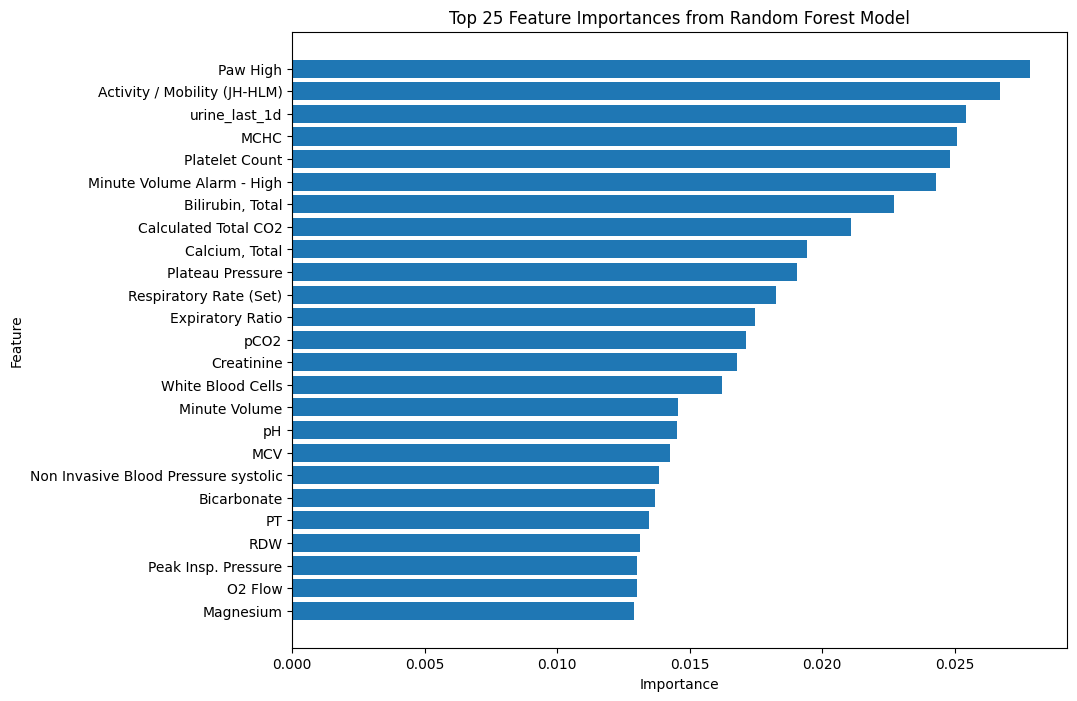

In [22]:
# Separate the target variable from the features
y_train = train_df_processed['readmitted']
y_cross_val = cross_val_df_processed['readmitted']
y_test = test_df_processed['readmitted']

# Drop the columns
X_train = train_df_processed.drop(['readmitted', 'subject_id', 'stay_id' , 'Vti High' , 'Base Excess'], axis=1)
X_cross_val = cross_val_df_processed.drop(['readmitted', 'subject_id' , 'stay_id' , 'Vti High' , 'Base Excess'], axis=1)
X_test = test_df_processed.drop(['readmitted', 'subject_id' , 'stay_id' , 'Vti High' , 'Base Excess'], axis=1)

# Step 1: Train the Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Step 2: Evaluate the model on the validation set
y_cross_val_pred = rf_model.predict(X_cross_val)
print("Validation Set Accuracy:", accuracy_score(y_cross_val, y_cross_val_pred))
print("Validation Set Classification Report:\n", classification_report(y_cross_val, y_cross_val_pred))

# Step 3: Evaluate the model on the test set
y_test_pred = rf_model.predict(X_test)
print("Test Set Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test Set Classification Report:\n", classification_report(y_test, y_test_pred))

# Step 4: Display the feature importances
importances = rf_model.feature_importances_
features = X_train.columns

# Combine feature names with their importances and sort them
feature_importances = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

top_features = feature_importances.head(25)

print("Top 25 Important Features:\n", top_features)

# Optional: Visualize the top 25 feature importances
plt.figure(figsize=(10, 8))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 25 Feature Importances from Random Forest Model')
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature on top
plt.show()


In [23]:
# Model evaluation
y_cross_val_pred = rf_model.predict(X_cross_val)
y_test_pred = rf_model.predict(X_test)

# Calculate metrics for the validation set
val_accuracy = accuracy_score(y_cross_val, y_cross_val_pred)
val_roc_auc = roc_auc_score(y_cross_val, rf_model.predict_proba(X_cross_val)[:, 1])
val_f1 = f1_score(y_cross_val, y_cross_val_pred)

# Calculate metrics for the test set
test_accuracy = accuracy_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])
test_f1 = f1_score(y_test, y_test_pred)

# Print the results
print("Validation Accuracy:", val_accuracy)
print("Validation ROC AUC:", val_roc_auc)
print("Validation F1 Score:", val_f1)
print("Test Accuracy:", test_accuracy)
print("Test ROC AUC:", test_roc_auc)
print("Test F1 Score:", test_f1)


Validation Accuracy: 0.9809027777777778
Validation ROC AUC: 0.9965828191741813
Validation F1 Score: 0.9316770186335404
Test Accuracy: 0.9826388888888888
Test ROC AUC: 0.9998813478879924
Test F1 Score: 0.9382716049382717


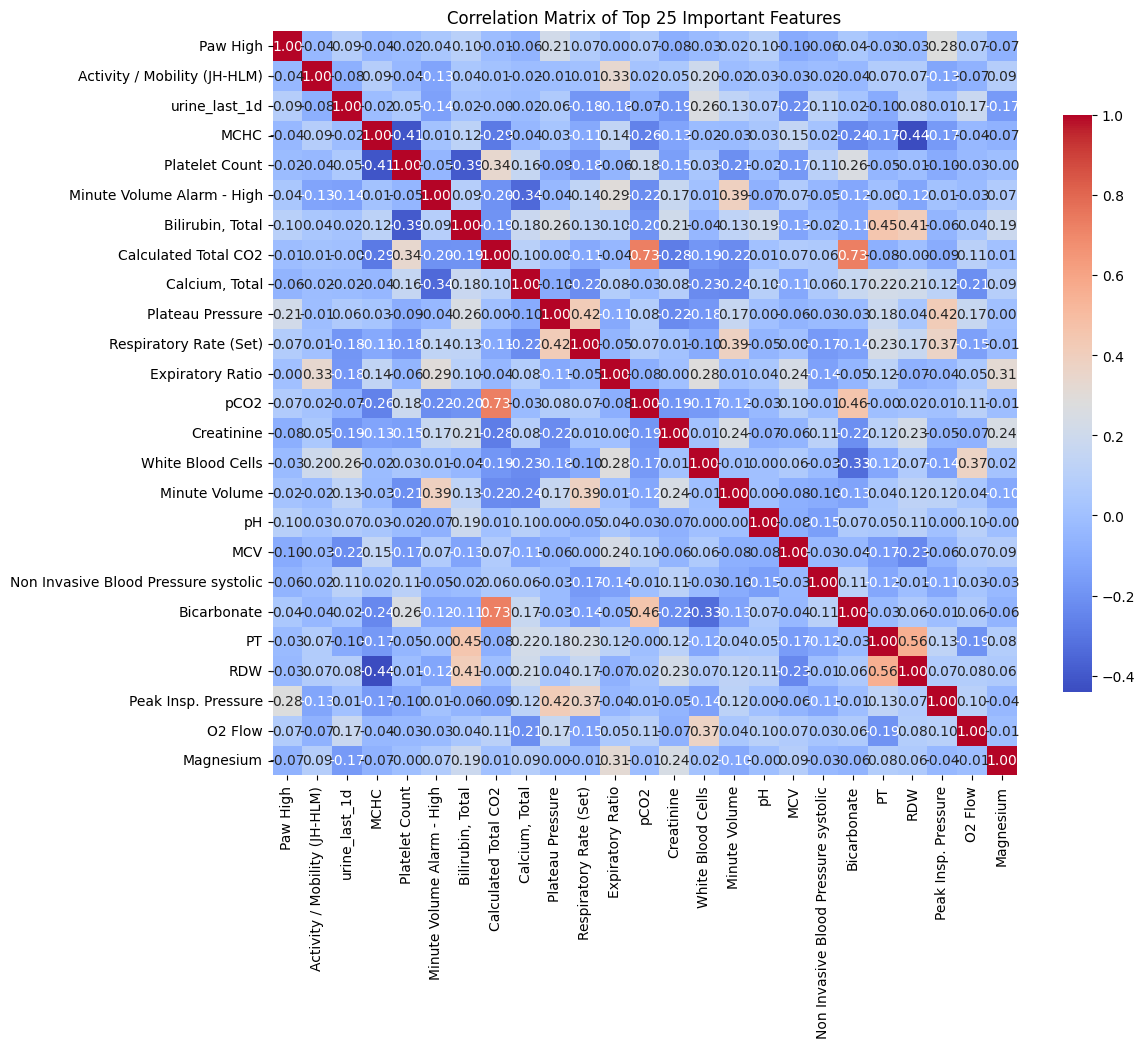

In [24]:
# Assuming train_df_processed contains the original training data with the correct feature names
# Extract the top 25 important features
top_25_features = feature_importances['Feature'].head(25)

# Subset the training data to only include these top 25 features
top_25_data = train_df_processed[top_25_features]

# Calculate the correlation matrix
correlation_matrix = top_25_data.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True, cbar_kws={"shrink": .75})
plt.title('Correlation Matrix of Top 25 Important Features')
plt.show()


In [25]:
# 'merged_df' is initial DataFrame
co2_nan_count = merged_df['Calculated Total CO2'].isnull().sum()
base_excess_nan_count = merged_df['Base Excess'].isnull().sum()

print(f"Number of NaN values in 'Calculated Total CO2': {co2_nan_count}")
print(f"Number of NaN values in 'Base Excess': {base_excess_nan_count}")

Number of NaN values in 'Calculated Total CO2': 1681
Number of NaN values in 'Base Excess': 1681


In [26]:
# 'merged_df' is initial DataFrame
number_of_rows = merged_df.shape[0]

print(f"Number of rows in 'merged_df': {number_of_rows}")

Number of rows in 'merged_df': 2879


In [27]:
# 'merged_df' is initial DataFrame
co2_nan_count = merged_df['Vti High'].isnull().sum()
base_excess_nan_count = merged_df['Expiratory Ratio'].isnull().sum()

print(f"Number of NaN values in 'Calculated Total CO2': {co2_nan_count}")
print(f"Number of NaN values in 'Base Excess': {base_excess_nan_count}")

Number of NaN values in 'Calculated Total CO2': 1751
Number of NaN values in 'Base Excess': 2071


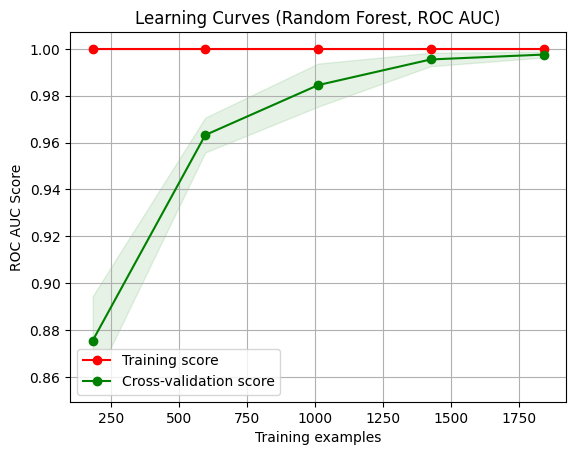

In [28]:
from sklearn.model_selection import learning_curve, StratifiedKFold

# Function to plot the learning curve
def plot_learning_curve(estimator, title, X, y, cv=None, n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    plt.figure()
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("ROC AUC Score")
    
    # Compute learning curve data
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring='roc_auc')
    
    # Calculate mean and standard deviation for the scores
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    val_scores_mean = np.mean(val_scores, axis=1)
    val_scores_std = np.std(val_scores, axis=1)
    
    plt.grid()

    # Plot shaded areas for standard deviations
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, val_scores_mean - val_scores_std,
                     val_scores_mean + val_scores_std, alpha=0.1, color="g")
    
    # Plot the mean scores
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, val_scores_mean, 'o-', color="g", label="Cross-validation score")

    plt.legend(loc="best")
    return plt

# Plot learning curve
title = "Learning Curves (Random Forest, ROC AUC)"
cv = StratifiedKFold(n_splits=5)  # 5-fold cross-validation
estimator = rf_model

# Combine the training and validation data
X_train_full = pd.concat([X_train, X_cross_val])
y_train_full = pd.concat([y_train, y_cross_val])

# Plot the learning curve
plot_learning_curve(estimator, title, X_train_full, y_train_full, cv=cv, n_jobs=-1)

# Show the plot
plt.show()
